In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:
import zipfile

with zipfile.ZipFile("archive (2).zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
import os

print(os.listdir("dataset"))

['index.html', 'KDDTrain+_20Percent.txt', 'nsl-kdd', 'KDDTrain+.txt', 'KDDTest1.jpg', 'KDDTest+.txt', 'KDDTrain+_20Percent.arff', 'KDDTest+.arff', 'KDDTest-21.arff', 'KDDTrain1.jpg', 'KDDTest-21.txt', 'KDDTrain+.arff']


In [ ]:
import pandas as pd

In [ ]:
columns = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
"wrong_fragment","urgent","hot","num_failed_logins","logged_in",
"num_compromised","root_shell","su_attempted","num_root",
"num_file_creations","num_shells","num_access_files","num_outbound_cmds",
"is_host_login","is_guest_login","count","srv_count","serror_rate",
"srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
"diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
"dst_host_same_srv_rate","dst_host_diff_srv_rate",
"dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
"dst_host_serror_rate","dst_host_srv_serror_rate",
"dst_host_rerror_rate","dst_host_srv_rerror_rate",
"label"
]

In [ ]:
df = pd.read_csv("dataset/KDDTrain+.txt", names=columns)

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,tcp,ftp_data,SF,491,0,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
0,udp,other,SF,146,0,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
0,tcp,private,S0,0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
0,tcp,http,SF,232,8153,0,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
0,tcp,http,SF,199,420,0,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
df.shape

(125973, 42)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = df.dropna()

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop("label", axis=1)
y = df["label"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9030760071442746

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.62      0.71        16
           1       0.61      0.73      0.67        15
           2       0.57      0.40      0.47        10
           3       0.58      0.50      0.54        14
           4       0.60      0.43      0.50        21
           5       0.47      0.39      0.42        18
           6       0.43      0.53      0.48        19
           7       0.50      0.35      0.41        26
           8       0.50      0.31      0.38        26
           9       0.56      0.60      0.58        30
          10       0.61      0.61      0.61        56
          11       0.77      0.77      0.77       146
          12       0.74      0.71      0.73       143
          13       0.52      0.48      0.50        85
          14       0.71      0.64      0.68       149
          15       0.85      0.89      0.87       795
          16       0.76    

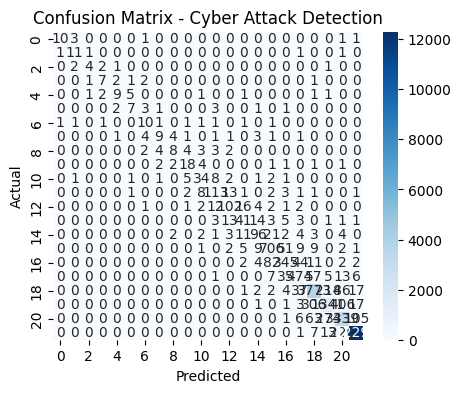

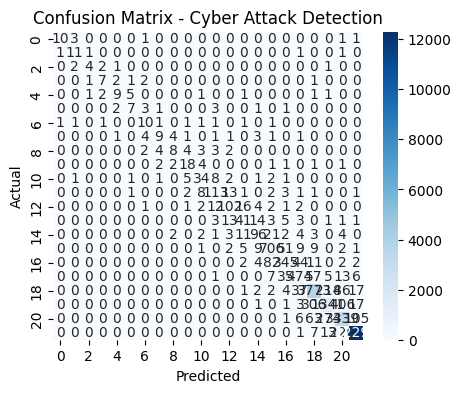

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Cyber Attack Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
iso_model = IsolationForest(contamination=0.1, random_state=42)

iso_model.fit(X_train)

anomaly_pred = iso_model.predict(X_test)

In [ ]:
# -1 = anomaly, 1 = normal
anomaly_labels = np.where(anomaly_pred == -1, 1, 0)

In [ ]:
print("Anomaly Detection Report:")
print(classification_report(y_test, anomaly_labels))

Anomaly Detection Report:
              precision    recall  f1-score   support

           0       0.00      0.94      0.00        16
           1       0.00      0.33      0.00        15
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        14
           4       0.00      0.00      0.00        21
           5       0.00      0.00      0.00        18
           6       0.00      0.00      0.00        19
           7       0.00      0.00      0.00        26
           8       0.00      0.00      0.00        26
           9       0.00      0.00      0.00        30
          10       0.00      0.00      0.00        56
          11       0.00      0.00      0.00       146
          12       0.00      0.00      0.00       143
          13       0.00      0.00      0.00        85
          14       0.00      0.00      0.00       149
          15       0.00      0.00      0.00       795
          16       0.00      0.00      0.00       492
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import datetime

def generate_alert(prediction):
    if prediction == 1:
        alert = "🚨 ALERT: Cyber Attack Detected!"
        risk = "HIGH"
    else:
        alert = "✅ Normal Activity"
        risk = "LOW"

    log = f"{datetime.datetime.now()} | {alert} | Risk: {risk}"
    print(log)

    return log

In [ ]:
sample_pred = rf_model.predict(X_test[:10])

for p in sample_pred:
    generate_alert(p)

2026-04-14 04:14:46.150109 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:46.150293 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:46.150312 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:46.150324 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:46.150336 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:46.150346 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:46.150355 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:46.150364 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:46.150372 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:46.150381 | ✅ Normal Activity | Risk: LOW


In [ ]:
with open("soc_alerts.log", "w") as f:
    for p in sample_pred:
        log = generate_alert(p)
        f.write(log + "\n")

2026-04-14 04:14:59.229445 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:59.229716 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:59.229741 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:59.229756 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:59.229770 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:59.229784 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:59.229796 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:59.229809 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:59.229821 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:14:59.229834 | ✅ Normal Activity | Risk: LOW


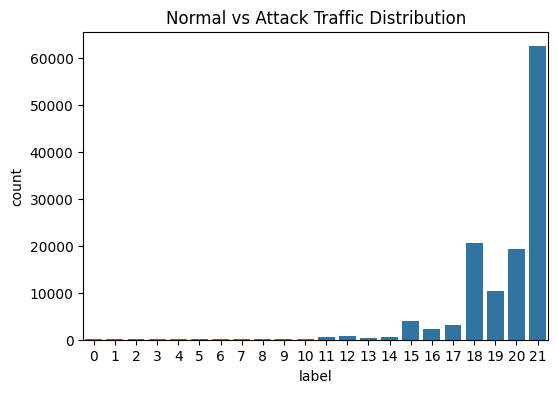

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Normal vs Attack Traffic Distribution")
plt.show()

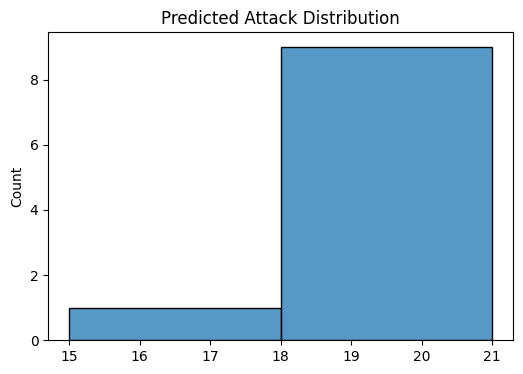

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(sample_pred, bins=2)
plt.title("Predicted Attack Distribution")
plt.show()

In [ ]:
import numpy as np

def simulate_attack_data(X_test):
    # randomly pick few samples
    return X_test[np.random.randint(0, len(X_test), 5)]

In [ ]:
fake_traffic = simulate_attack_data(X_test)

preds = rf_model.predict(fake_traffic)

for p in preds:
    generate_alert(p)

2026-04-14 04:16:06.456220 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:16:06.456365 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:16:06.456387 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:16:06.456402 | ✅ Normal Activity | Risk: LOW
2026-04-14 04:16:06.456416 | ✅ Normal Activity | Risk: LOW


In [ ]:
!pip install streamlit pyngrok

In [ ]:
import joblib

joblib.dump(rf_model, "cyber_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from google.colab import files

files.download("cyber_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print(os.listdir())

['.config', 'scaler.pkl', 'cyber_model.pkl', 'dataset', 'soc_alerts.log', 'archive (2).zip', 'app.py', 'sample_data']


In [ ]:
import joblib

joblib.dump(rf_model, "cyber_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

Model saved successfully!
